In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

print("tensorflow hazır")

# Veriyi yükle
df = pd.read_excel(
    "/Users/aleynagulkazdal/Desktop/Bitirme/WiAR-master/distance_factor_activity_data/1m_data/sample_antenna_A.xls",
    header=None
)

print("df shape:", df.shape)

# Normalizasyon
df_normalized = (df - df.min()) / (df.max() - df.min())

# Model formatı
X = df_normalized.values.reshape(-1, 200, 1)

# Etiketler
labels = np.repeat(np.arange(16), 300)

print("X shape:", X.shape)
print("labels shape:", labels.shape)

# Train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

tensorflow hazır
df shape: (4800, 200)
X shape: (4800, 200, 1)
labels shape: (4800,)
Eğitim seti: (3840, 200, 1)
Test seti: (960, 200, 1)


In [3]:

model = Sequential([
    # CNN katmanları
    Conv1D(64,kernel_size=3, activation='relu', input_shape=(200, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    
    #LSTM katmanları
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    
    # Çıkış katmanı
    Dense (64, activation='relu'),
    Dense(16, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/Users/aleynagulkazdal/csi_proje/CSI-GestureID-CNNLSTM/csi_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 198, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 99, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 97, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,568 (310.81 KB)

 Trainable params: 79,568 (310.81 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Modeli eğit
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0664 - loss: 2.7732 - val_accuracy: 0.0885 - val_loss: 2.7602
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0736 - loss: 2.7518 - val_accuracy: 0.0495 - val_loss: 2.7908
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0697 - loss: 2.7679 - val_accuracy: 0.0326 - val_loss: 2.7711
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0983 - loss: 2.6735 - val_accuracy: 0.1003 - val_loss: 2.6629
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1139 - loss: 2.6162 - val_accuracy: 0.0885 - val_loss: 2.6027
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1139 - loss: 2.5994 - val_accuracy: 0.1250 - val_loss: 2.5756
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1341 - loss: 2.5694 - val_accuracy: 0.1589 - val_loss: 2.5451
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1595 - loss: 2.5220 - val_accuracy: 0.1784 - v

In [24]:
# Test setinde değerlendir
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Doğruluğu: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Doğruluğu: 40.73%
Test Loss: 1.6141


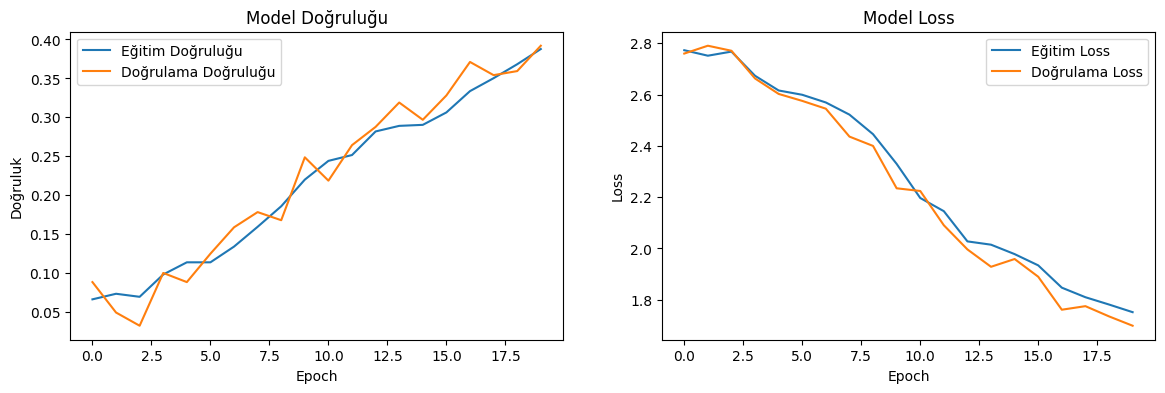

In [25]:
import matplotlib.pyplot as plt

fig , (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
ax1.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
ax1.set_title('Model Doğruluğu')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Doğruluk')
ax1.legend()

ax2.plot(history.history['loss'], label='Eğitim Loss')
ax2.plot(history.history['val_loss'], label='Doğrulama Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()    

plt.show()

In [4]:
history2 = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.0605 - loss: 2.7733 - val_accuracy: 0.0651 - val_loss: 2.7694
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.0768 - loss: 2.7638 - val_accuracy: 0.0951 - val_loss: 2.7239
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1032 - loss: 2.6526 - val_accuracy: 0.0833 - val_loss: 2.6204
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1084 - loss: 2.6054 - val_accuracy: 0.1016 - val_loss: 2.5929
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1120 - loss: 2.6015 - val_accuracy: 0.1289 - val_loss: 2.5703
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1357 - loss: 2.5484 - val_accuracy: 0.1315 - val_loss: 2.4841
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1641 - loss: 2.4782 - val_accuracy: 0.1576 - val_loss: 2.3778
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1745 - loss: 2.4165 - val_accuracy: 0.1771 - v

In [5]:
# Test setinde değerlendir
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Doğruluğu: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Doğruluğu: 59.17%
Test Loss: 1.1928


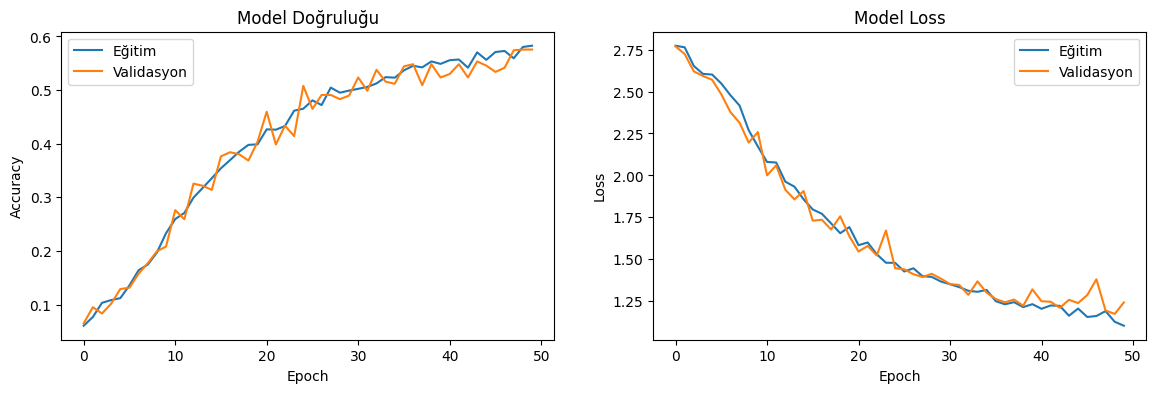

In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history2.history['accuracy'], label='Eğitim')
ax1.plot(history2.history['val_accuracy'], label='Validasyon')
ax1.set_title('Model Doğruluğu')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history2.history['loss'], label='Eğitim')
ax2.plot(history2.history['val_loss'], label='Validasyon')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

In [10]:
history2 = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5853 - loss: 1.1264 - val_accuracy: 0.5430 - val_loss: 1.2279
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5794 - loss: 1.1339 - val_accuracy: 0.5977 - val_loss: 1.1470
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5986 - loss: 1.0890 - val_accuracy: 0.5781 - val_loss: 1.1629
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5967 - loss: 1.0864 - val_accuracy: 0.5807 - val_loss: 1.1780
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6107 - loss: 1.0455 - val_accuracy: 0.5638 - val_loss: 1.2000
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6113 - loss: 1.0620 - val_accuracy: 0.5794 - val_loss: 1.1967
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6165 - loss: 1.0252 - val_accuracy: 0.6081 - val_loss: 1.1261
Epoch 8/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6208 - loss: 1.0498 - val_accuracy: 0.

KeyboardInterrupt: 

In [ ]:
# Test setinde değerlendir
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Doğruluğu: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Doğruluğu: 69.38%
Test Loss: 1.0604


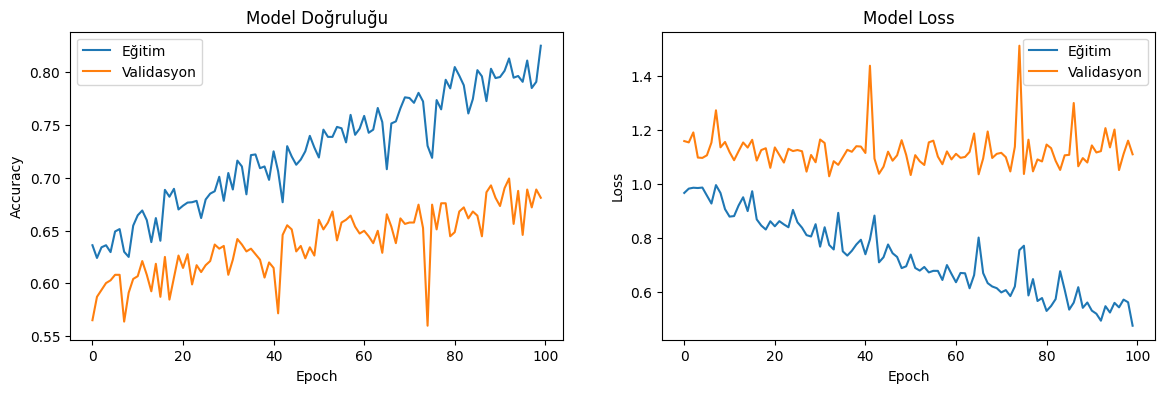

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history2.history['accuracy'], label='Eğitim')
ax1.plot(history2.history['val_accuracy'], label='Validasyon')
ax1.set_title('Model Doğruluğu')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history2.history['loss'], label='Eğitim')
ax2.plot(history2.history['val_loss'], label='Validasyon')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

In [ ]:
model2 = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(200, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history3 = model2.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.0583 - loss: 2.7764 - val_accuracy: 0.0625 - val_loss: 2.7706
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0661 - loss: 2.7642 - val_accuracy: 0.0768 - val_loss: 2.7492
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0951 - loss: 2.6857 - val_accuracy: 0.0885 - val_loss: 2.6599
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1022 - loss: 2.6369 - val_accuracy: 0.0690 - val_loss: 2.6474
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1012 - loss: 2.6282 - val_accuracy: 0.1003 - val_loss: 2.5976
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1094 - loss: 2.6052 - val_accuracy: 0.1029 - val_loss: 2.5835
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.1107 - loss: 2.5965 - val_accuracy: 0.1198 - val_loss: 2.5615
Epoch 8/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.1211 - loss: 2.5748 - val_accuracy: 0.

In [ ]:
test_loss, test_accuracy = model2.evaluate(X_test, y_test, verbose=0)
print(f"Test Doğruluğu: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Doğruluğu: 56.88%
Test Loss: 1.1050


In [ ]:
model3 = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(200, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(16, activation='softmax')
])

model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history4 = model3.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, verbose=1)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.0628 - loss: 2.7702 - val_accuracy: 0.0716 - val_loss: 2.7465
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.0850 - loss: 2.6904 - val_accuracy: 0.0898 - val_loss: 2.6314
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.1029 - loss: 2.6242 - val_accuracy: 0.0690 - val_loss: 2.6407
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.0960 - loss: 2.6141 - val_accuracy: 0.0951 - val_loss: 2.6502
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.1156 - loss: 2.5899 - val_accuracy: 0.1367 - val_loss: 2.5685
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.1104 - loss: 2.5898 - val_accuracy: 0.1055 - val_loss: 2.5655
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.1120 - loss: 2.6029 - val_accuracy: 0.0768 - val_loss: 2.7241
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1211 - loss: 2.6126 - val_accuracy: 0.

In [ ]:
test_loss, test_accuracy = model3.evaluate(X_test, y_test, verbose=0)
print(f"Test Doğruluğu: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Doğruluğu: 68.33%
Test Loss: 1.0451


In [11]:
df_a = pd.read_excel(
    "/Users/aleynagulkazdal/Desktop/Bitirme/WiAR-master/distance_factor_activity_data/1m_data/sample_antenna_A.xls",
    header=None
)
df_b = pd.read_excel(
    "/Users/aleynagulkazdal/Desktop/Bitirme/WiAR-master/distance_factor_activity_data/1m_data/sample_antenna_B.xls",
    header=None
)
df_c = pd.read_excel(
    "/Users/aleynagulkazdal/Desktop/Bitirme/WiAR-master/distance_factor_activity_data/1m_data/sample_antenna_C.xls",
    header=None
)

print("A:", df_a.shape)
print("B:", df_b.shape)
print("C:", df_c.shape)

A: (4800, 200)
B: (4800, 200)
C: (4800, 200)


In [12]:
import numpy as np

# Normalizasyon
df_a_norm = (df_a - df_a.min()) / (df_a.max() - df_a.min())
df_b_norm = (df_b - df_b.min()) / (df_b.max() - df_b.min())
df_c_norm = (df_c - df_c.min()) / (df_c.max() - df_c.min())

# Üç anteni birleştir
X_combined = np.concatenate([
    df_a_norm.values.reshape(-1, 200, 1),
    df_b_norm.values.reshape(-1, 200, 1),
    df_c_norm.values.reshape(-1, 200, 1)
], axis=2)

print("Birleştirilmiş veri şekli:", X_combined.shape)

# Etiketler
labels = np.repeat(np.arange(16), 300)
labels_combined = np.tile(labels, 1)

# Train/test böl
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, labels, test_size=0.2, random_state=42
)

print("Eğitim:", X_train.shape)
print("Test:", X_test.shape)

Birleştirilmiş veri şekli: (4800, 200, 3)
Eğitim: (3840, 200, 3)
Test: (960, 200, 3)


In [13]:
model4 = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(200, 3)),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(16, activation='softmax')
])

model4.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history5 = model4.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/100


/Users/aleynagulkazdal/csi_proje/CSI-GestureID-CNNLSTM/csi_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.1247 - loss: 2.6052 - val_accuracy: 0.2005 - val_loss: 2.3660
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.1947 - loss: 2.3344 - val_accuracy: 0.2161 - val_loss: 2.2385
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.2116 - loss: 2.2555 - val_accuracy: 0.2083 - val_loss: 2.2604
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.2412 - loss: 2.1655 - val_accuracy: 0.2669 - val_loss: 2.1191
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.2796 - loss: 2.0609 - val_accuracy: 0.3294 - val_loss: 1.9689
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3190 - loss: 1.9549 - val_accuracy: 0.3555 - val_loss: 1.8517
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3496 - loss: 1.8717 - val_accuracy: 0.3776 - val_loss: 1.8290
Epoch 8/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.3923 - loss: 1.7363 - val_accuracy: 0.3607 - val_l

In [14]:
test_loss, test_accuracy = model4.evaluate(X_test, y_test, verbose=0)
print(f"Test Doğruluğu: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Doğruluğu: 79.69%
Test Loss: 0.7604
